In [1]:
%load_ext autoreload
%autoreload 2

from tinylang.experiment import Experiment

import yaml
import pyvene as pv
import os
import pandas as pd
import torch
import numpy as np
import plotnine as p9

name = "ar_32_nope/mamba___256___1e-03"
# name = "ar_32/attention___128___3e-04"
config_path = f"/nlp/scr/aryaman/tinylang/experiments/configs/{name}.yaml"
model_path = f"/nlp/scr/aryaman/tinylang/experiments/logs/{name}/model.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
    if config["model"]["config"]["mixer_type"].startswith("mamba"):
        config["model"]["config"]["mixer_type"] = "mamba_no_causal_conv1d"
    config["training"]["log_dir"] = "."
    config["evaluators"].append({'class': 'InterchangeEvaluator', 'config': {'run_every_n_steps': 1000, 'swap_corrupt_and_orig': True}})
print(config['evaluators'])

# load model
exp = Experiment.from_config(
    config=config
)
exp.model.load(model_path)
exp.verbose = True
exp.model.model.to(device)
exp.model.model.eval()

nnsight is not detected. Please install via 'pip install nnsight' for nnsight backend.
[{'class': 'SummaryEvaluator', 'config': {'run_every_n_steps': 200}}, {'class': 'InterchangeEvaluator', 'config': {'run_every_n_steps': 1000}}, {'class': 'InterchangeEvaluator', 'config': {'run_every_n_steps': 1000, 'swap_corrupt_and_orig': True}}]
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi mamba!
hi m

LanguageModel(
  (backbone): LMBackbone(
    (embeddings): TokenEmbeddings(
      (word_embeddings): Embedding(8196, 256)
    )
    (layers): Sequential(
      (0): MambaBlock(
        (sequence_mixer): MambaNoCausalConv1D(
          (in_proj): Linear(in_features=256, out_features=1024, bias=False)
          (conv1d_input): Identity()
          (conv1d): Conv1d(512, 512, kernel_size=(4,), stride=(1,), padding=(3,), groups=512)
          (conv1d_output): Identity()
          (act_input): Identity()
          (act): SiLU()
          (act_output): Identity()
          (x_proj): Linear(in_features=512, out_features=48, bias=False)
          (dt_proj): Linear(in_features=16, out_features=512, bias=True)
          (out_proj): Linear(in_features=512, out_features=256, bias=False)
        )
        (norm): RMSNorm()
      )
      (1): MambaBlock(
        (sequence_mixer): MambaNoCausalConv1D(
          (in_proj): Linear(in_features=256, out_features=1024, bias=False)
          (conv1d_input): 

In [2]:
from tinylang.model import LanguageModel

for batch_idx in range(len(exp.language.evalsets["test"]["probing_schemas"])):
    max_pos = exp.language.evalsets["test"]["probing_schemas"][batch_idx]['queries']['target_item']['pos']
    exp.language.evalsets["test"]["probing_schemas"][batch_idx]['queries'].update({
        f"pos__{i}": {
            "pos": i,
            "target_distribution": None,
        }
        for i in range(0, max_pos + 1)
    })

pv.type_to_module_mapping[LanguageModel].update({
    "conv_input": ("backbone.layers[%s].sequence_mixer.conv1d_input", 
                        pv.models.constants.CONST_INPUT_HOOK),
    "conv_output": ("backbone.layers[%s].sequence_mixer.conv1d_output", 
                        pv.models.constants.CONST_INPUT_HOOK),
    "in_proj_input": ("backbone.layers[%s].sequence_mixer.in_proj", 
                        pv.models.constants.CONST_INPUT_HOOK),
    "in_proj_output": ("backbone.layers[%s].sequence_mixer.in_proj", 
                        pv.models.constants.CONST_OUTPUT_HOOK),
    "out_proj_input": ("backbone.layers[%s].sequence_mixer.out_proj", 
                        pv.models.constants.CONST_INPUT_HOOK),
    "out_proj_output": ("backbone.layers[%s].sequence_mixer.out_proj", 
                        pv.models.constants.CONST_OUTPUT_HOOK),
    "act_input": ("backbone.layers[%s].sequence_mixer.act_input", 
                        pv.models.constants.CONST_INPUT_HOOK),
    "act_output": ("backbone.layers[%s].sequence_mixer.act_output", 
                        pv.models.constants.CONST_INPUT_HOOK),
})
# pv.type_to_dimension_mapping[LanguageModel].update({
#     "conv_input": ("d_model*2",),
#     "conv_output": ("d_model*2",),
#     "in_proj_input": ("d_model",),
#     "in_proj_output": ("d_model*4",),
#     "out_proj_input": ("d_model*2",),
#     "out_proj_output": ("d_model",),
# })

# eval on all data
full_eval_length = len(exp.language.stats["test"]["query_orig_target_orig_dist"])
# exp.training_config.num_eval_steps = int(full_eval_length / exp.training_config.eval_batch_size)
exp.training_config.num_eval_steps = 1
# exp.training_config.eval_batch_size = 1
exp.training_config.__dict__

# exp.model.components = ["block_input", "block_output", "attention_input", "attention_output", "conv_input", "act_input", "out_proj_input"]
exp.model.components = ["conv_input", "conv_output", "act_input", "act_output"]

In [3]:
exp.model.components = ["block_input", "block_output", "attention_input", "attention_output",
                        "conv_input", "conv_output", "act_input", "act_output", "out_proj_input",
                        "out_proj_output"]

In [4]:
# run eval step
exp.eval_step(0, split="test", evaluators=exp.evaluators["test"])

Evals:   0%|          | 0/1 [00:00<?, ?it/s]

{}
hi result torch.Size([64, 1, 256]) 0.146% 0.146% 100.000%
{}
hi result torch.Size([64, 1, 256]) 100.000% 100.000% 100.000%
{}
hi result torch.Size([64, 1, 256]) 100.000% 100.000% 100.000%
{}
hi result torch.Size([64, 1, 256]) 100.000% 100.000% 100.000%
{}
hi result torch.Size([64, 1, 256]) 100.000% 100.000% 100.000%
{}
hi result torch.Size([64, 1, 256]) 100.000% 100.000% 100.000%
{}
hi result torch.Size([64, 1, 256]) 93.750% 93.750% 100.000%
{}
hi result torch.Size([64, 1, 256]) 100.000% 100.000% 100.000%
{}
hi result torch.Size([64, 1, 256]) 93.762% 93.762% 100.000%
{}
hi result torch.Size([64, 1, 256]) 100.000% 100.000% 100.000%
{}
hi result torch.Size([64, 1, 256]) 95.331% 95.331% 100.000%
{}
hi result torch.Size([64, 1, 256]) 100.000% 100.000% 100.000%
{}
hi result torch.Size([64, 1, 256]) 93.756% 93.756% 100.000%
{}
hi result torch.Size([64, 1, 256]) 100.000% 100.000% 100.000%
{}
hi result torch.Size([64, 1, 256]) 95.312% 95.312% 100.000%
{}
hi result torch.Size([64, 1, 256]) 1

Evals: 100%|██████████| 1/1 [01:48<00:00, 108.79s/it]


{}
hi result torch.Size([64, 1, 256]) 0.232% 0.232% 100.000%
{}
hi result torch.Size([64, 1, 256]) 0.342% 0.342% 100.000%


Post-evals: 100%|██████████| 3/3 [00:00<00:00, 62.30it/s]

                KEY.query_item.pred_prob: 92.72507%
                    query_item.pred_prob: 92.72507%


{}

## Vis

In [5]:
all_vals = []
for key, val in exp.evaluators["test"][1].all_eval_stats[0].items():
    if "original" not in key and "restored_prob" in key and "corrupted" not in key and "pos__" in key:
        all_vals.append((val, 'FWD___' + key))
for key, val in exp.evaluators["test"][2].all_eval_stats[0].items():
    if "original" not in key and "restored_prob" in key and "corrupted" not in key and "pos__" in key:
        all_vals.append((val, 'BWD___' + key))

all_vals.sort(key=lambda x: x[0], reverse=True)
for val, key in all_vals:
    print(f"{key:>80}: {[f'{v:>6.3f}' for v in val]}")

data = []
for val, key in all_vals:
    for i in range(len(val)):
        query_item_orig_pos = exp.language.evalsets["test"]["probing_schemas"][i]['queries']['query_item_orig']['pos']
        data.append({
            "pos": int(key.split(".")[3].split("__")[-1]),
            "pos_diff": int(key.split(".")[3].split("__")[-1]) - query_item_orig_pos,
            "corrupted": key.split(".")[2],
            "direction": key.split(".")[0].split("___")[0],
            "layer": int(key.split(".")[0].split("___")[1]),
            "metric": val[i],
            "idx": i,
            "component": key.split(".")[4],
        })


                     BWD___0.KEY.query_item_orig.pos__25.act_input.restored_prob: [' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 0.957', ' 1.000', ' 0.957', ' 0.902', ' 1.000', ' 1.000', ' 0.836', ' 1.000', ' 1.000', ' 0.992', ' 1.000', ' 1.000', ' 1.000', ' 0.377', ' 1.000', ' 1.000', ' 0.146', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 0.000', ' 1.000', ' 1.000', ' 1.000', ' 0.042', ' 0.992', ' 0.000', ' 0.992', ' 1.000', ' 1.000', ' 1.000', ' 0.992', ' 1.000', ' 0.977', ' 1.000', ' 1.000', ' 0.961', ' 1.000', ' 0.902', ' 0.000', ' 1.000', ' 0.200', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 0.992', ' 1.000', ' 1.000']
                    BWD___0.KEY.query_item_orig.pos__25.act_output.restored_prob: [' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 1.000', ' 0.957', ' 1.000', ' 0.957', ' 0.902', ' 1.000', ' 1.000', ' 0.836', ' 1.000', ' 1.000', ' 0.

In [6]:
df = pd.DataFrame(data)
df

,pos,pos_diff,corrupted,direction,layer,metric,idx,component
0,25,8,query_item_orig,BWD,0,1.000000e+00,0,act_input
1,25,24,query_item_orig,BWD,0,1.000000e+00,1,act_input
2,25,24,query_item_orig,BWD,0,1.000000e+00,2,act_input
3,25,0,query_item_orig,BWD,0,1.000000e+00,3,act_input
4,25,8,query_item_orig,BWD,0,1.000000e+00,4,act_input
...,...,...,...,...,...,...,...,...
184315,26,19,query_item_orig,FWD,1,3.816392e-16,59,conv_output
184316,26,5,query_item_orig,FWD,1,1.251465e-09,60,conv_output
184317,26,13,query_item_orig,FWD,1,1.568878e-11,61,conv_output
184318,26,9,query_item_orig,FWD,1,5.227781e-22,62,conv_output


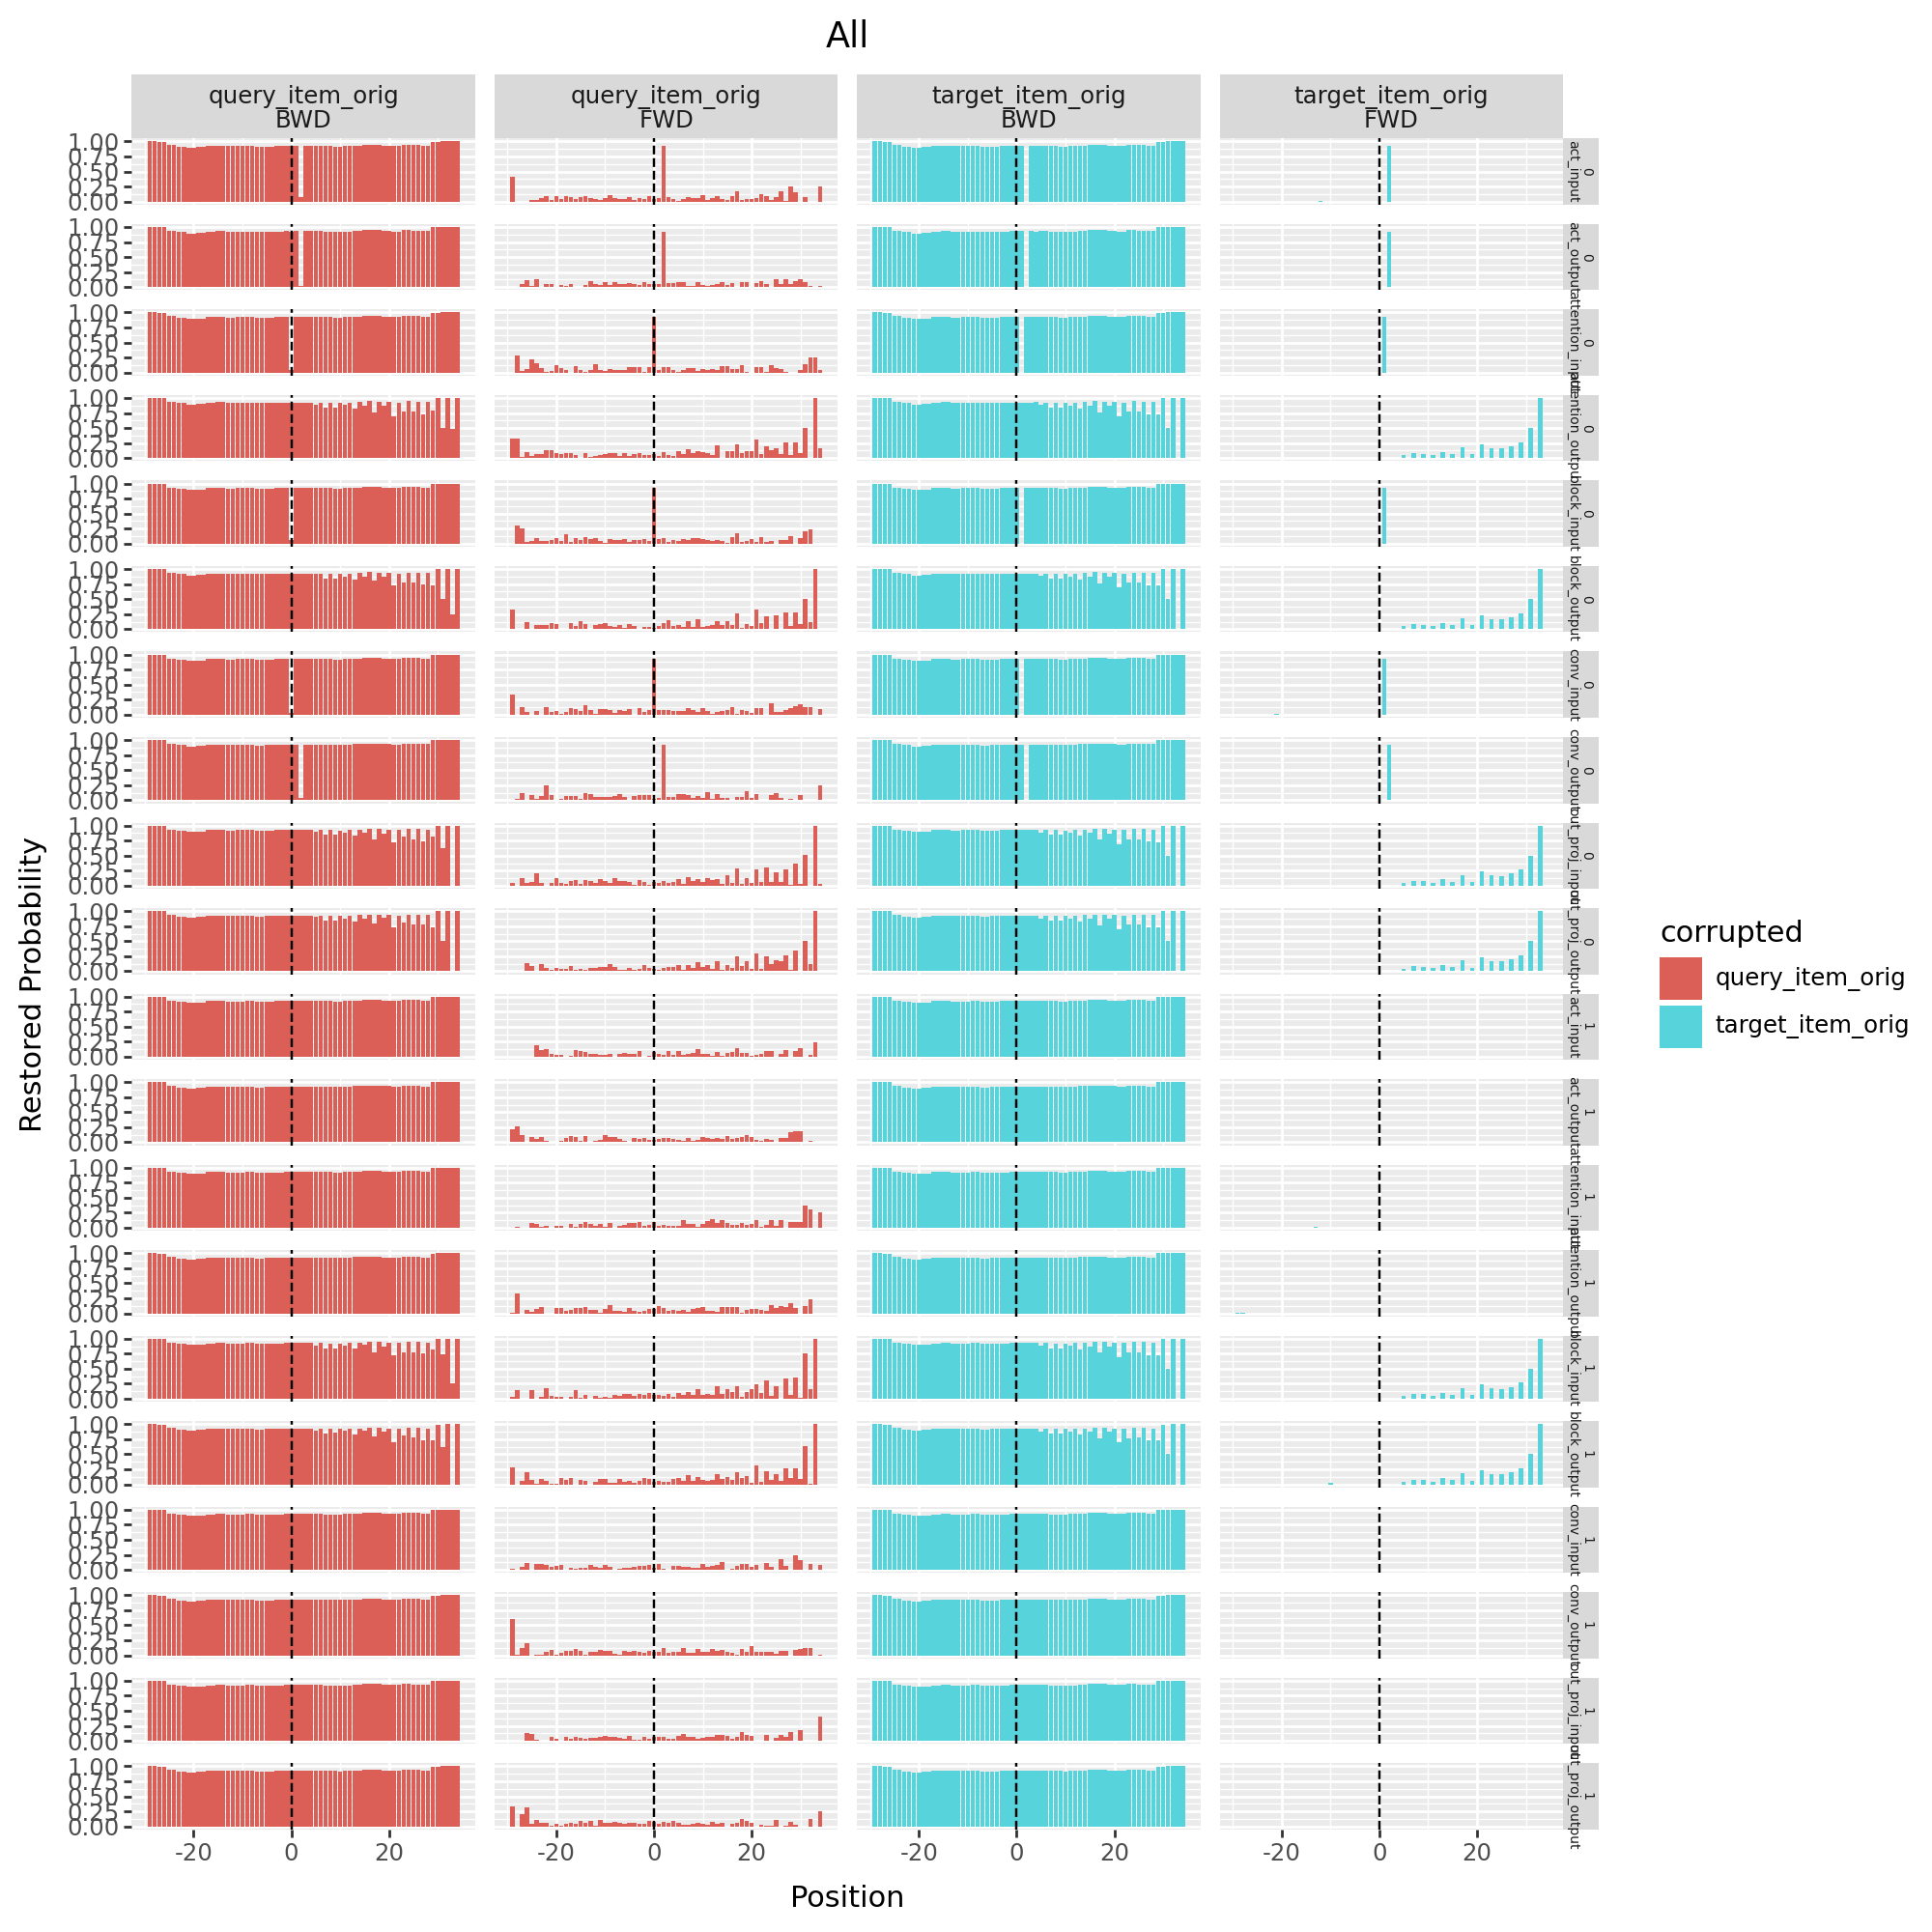

In [8]:
df = pd.DataFrame(data)
plot = (
    p9.ggplot(df, p9.aes(x="pos_diff", y="metric", fill="corrupted"))
    + p9.geom_bar(stat="summary")
    + p9.facet_grid("layer + component ~ corrupted + direction")
    + p9.labs(x="Position", y="Restored Probability")
    + p9.geom_vline(xintercept=0, color="black", linetype="dashed")
    # + p9.geom_text(df[(df["restored_prob"] > 0.1)], p9.aes(x="pos_diff", y="restored_prob", label="pos"), size=5, nudge_y=0.03)
    + p9.ggtitle(f"All")
    + p9.theme(
        strip_text_y=p9.element_text(size=5),
        figure_size=(10, 10),
    )
)
plot.show()

In [ ]:
df = pd.DataFrame(data)
for idx in df["idx"].unique():
    query_item_orig_pos = exp.language.evalsets["test"]["probing_schemas"][idx]['queries']['query_item_orig']['pos']
    plot = (
        p9.ggplot(df[df["idx"] == idx], p9.aes(x="pos_diff", y="restored_prob", fill="corrupted"))
        + p9.geom_bar(stat="identity")
        + p9.facet_grid("layer + component ~ corrupted")
        + p9.labs(x="Position", y="Restored Probability")
        + p9.geom_vline(xintercept=0, color="black", linetype="dashed")
        + p9.geom_text(df[(df["idx"] == idx) & (df["restored_prob"] > 0.1)], p9.aes(x="pos_diff", y="restored_prob", label="pos"), size=5, nudge_y=0.03)
        + p9.ggtitle(f"Query {idx}, orig pos {query_item_orig_pos}")
        + p9.theme(
            strip_text_y=p9.element_text(size=5),
            figure_size=(10, 10),
        )
    )
    plot.show()